In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pickle

In [24]:
print(f"TF version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TF version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
import sys
print(sys.version)
print(sys.executable)

3.11.15 (main, Jun 11 2026, 15:20:16) [GCC 14.3.0]
/home/h/anaconda3/envs/tf-gpu/bin/python


In [26]:
DATA_PATH = 'RML2016.10a_dict.pkl'

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

In [27]:
all_keys = data.keys()
unique_mod_types = sorted(list(set([key[0] for key in all_keys])))
unique_snr_values = sorted(list(set([key[1] for key in all_keys])))

mods = unique_mod_types
snrs = unique_snr_values

X, Y, snr_labels = [], [], []

for mod_idx, mod_type in enumerate(mods):
    for snr_val in snrs:
        current_key = (mod_type, snr_val)
        if current_key in data:
            samples = data[current_key]          # shape: (1000, 2, 128)
            X.append(samples)
            Y.append(np.full(len(samples), mod_idx))
            snr_labels.append(np.full(len(samples), snr_val))

X          = np.vstack(X)               # (220000, 2, 128)
Y          = np.concatenate(Y)          # (220000,)
snr_labels = np.concatenate(snr_labels) # (220000,)

Y_cat = to_categorical(Y, num_classes=len(mods))  # (220000, 11)

X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X, Y_cat, snr_labels, test_size=0.2, random_state=42
)

# Transpose for Conv1D: (N, 2, 128) → (N, 128, 2)
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

print(f"X_train: {X_train.shape}")  # expect (176000, 128, 2)
print(f"X_test:  {X_test.shape}")   # expect (44000, 128, 2)
print(f"Mods:    {mods}")

X_train: (176000, 128, 2)
X_test:  (44000, 128, 2)
Mods:    ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [28]:
def build_branch(inp):
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    return x

raw_input = Input(shape=(128, 2), name='raw_iq')

# Branch 1: raw IQ
b1 = build_branch(raw_input)

# Branch 2: FFT mag+phase
def fft_features(x):
    iq = tf.cast(x, tf.float32)
    cplx = tf.complex(iq[..., 0], iq[..., 1])
    fft = tf.signal.fft(cplx)
    mag = tf.abs(fft)
    phase = tf.math.angle(fft)
    return tf.stack([mag, phase], axis=-1)

fft_inp = layers.Lambda(fft_features, output_shape=(128, 2), name='fft_branch')(raw_input)
b2 = build_branch(fft_inp)

# Branch 3: envelope+phase
def envelope_features(x):
    iq = tf.cast(x, tf.float32)
    I, Q = iq[..., 0], iq[..., 1]
    env = tf.sqrt(I**2 + Q**2 + 1e-8)
    phase = tf.math.atan2(Q, I)
    return tf.stack([env, phase], axis=-1)

env_inp = layers.Lambda(envelope_features, output_shape=(128, 2), name='env_branch')(raw_input)
b3 = build_branch(env_inp)

# Branch 4: cumulants (NEW)
def cumulant_features(x):
    iq = tf.cast(x, tf.float32)
    I, Q = iq[..., 0], iq[..., 1]
    s = tf.complex(I, Q)
    conj_s = tf.math.conj(s)

    M20 = tf.reduce_mean(s * s, axis=1)
    M21 = tf.reduce_mean(s * conj_s, axis=1)
    M40 = tf.reduce_mean(s * s * s * s, axis=1)
    M41 = tf.reduce_mean(s * s * s * conj_s, axis=1)
    M42 = tf.reduce_mean(s * s * conj_s * conj_s, axis=1)

    C20 = M20
    C21 = tf.math.real(M21)
    C40 = M40 - 3 * M20**2
    C41 = M41 - 3 * M20 * M21
    C42 = tf.math.real(M42) - tf.abs(M20)**2 - 2 * C21**2

    power = tf.reduce_mean(I**2 + Q**2, axis=1)

    feats = tf.stack([
        tf.math.real(C20), tf.math.imag(C20),
        C21,
        tf.math.real(C40), tf.math.imag(C40),
        tf.math.real(C41), tf.math.imag(C41),
        C42,
        power
    ], axis=-1)
    return feats

cum_inp = layers.Lambda(cumulant_features, output_shape=(9,), name='cumulant_branch')(raw_input)
b4 = layers.Dense(64, activation='relu')(cum_inp)
b4 = layers.BatchNormalization()(b4)
b4 = layers.Dense(32, activation='relu')(b4)
b4 = layers.BatchNormalization()(b4)

# Fusion
merged = layers.concatenate([b1, b2, b3, b4])
x = layers.Dense(256, activation='relu')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(11, activation='softmax', name='output')(x)

model_v2 = Model(inputs=raw_input, outputs=out, name='ensemble_multibranchcnn_v2')
model_v2.summary()

Model: "ensemble_multibranchcnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_iq (InputLayer) │ (None, 128, 2)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fft_branch (Lambda) │ (None, 128, 2)    │          0 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ env_branch (Lambda) │ (None, 128, 2)    │          0 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 128, 64)   │        448 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 128, 64)   │        448 │ fft_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 128, 64)   │        448 │ env_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cumulant_branch     │ (None, 9)         │          0 │ raw_iq[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        640 │ cumulant_branch[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 372,843 (1.42 MB)

 Trainable params: 369,963 (1.41 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [29]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience = 10, restore_best_weights = True, monitor = 'val_accuracy'),
    ReduceLROnPlateau(factor = 0.5, patience=5, monitor = 'val_loss', min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras',
                    save_best_only = True, monitor='val_accuracy', verbose =1)
]

history = model.fit(
    X_train, Y_train,validation_split=0.1,
    batch_size = 1024,
    epochs = 100,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/100


I0000 00:00:1781981258.999381    1407 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101194__.94


154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5661 - loss: 1.1557

I0000 00:00:1781981272.765693    1405 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101194__.94


155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5661 - loss: 1.1557
Epoch 1: val_accuracy improved from None to 0.28216, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.5619 - loss: 1.1645 - val_accuracy: 0.2822 - val_loss: 2.2607 - learning_rate: 0.0010
Epoch 2/100
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5620 - loss: 1.1654
Epoch 2: val_accuracy did not improve from 0.28216
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.5632 - loss: 1.1640 - val_accuracy: 0.1455 - val_loss: 7.1671 - learning_rate: 0.0010
Epoch 3/100
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5665 - loss: 1.1569
Epoch 3: val_accuracy did not improve from 0.28216
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.5657 - loss: 1.1594 - val_accuracy: 0.2669 - val_loss: 3.4029 - learning_rate: 0.0010
Epoch 4/100
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5648 - los

In [36]:
with open('history_v2_local.json', 'w') as f:
    json.dump(history.history, f)

In [37]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras', custom_objects={
    'fft_features': fft_features,
    'envelope_features': envelope_features
})

all_preds = model.predict(X_test, batch_size=1024)

y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(all_preds, axis=1)

snr_acc = {}
for s in sorted(set(snr_test)):
    mask = snr_test == s
    snr_acc[s] = (y_pred[mask] == y_true[mask]).mean()

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


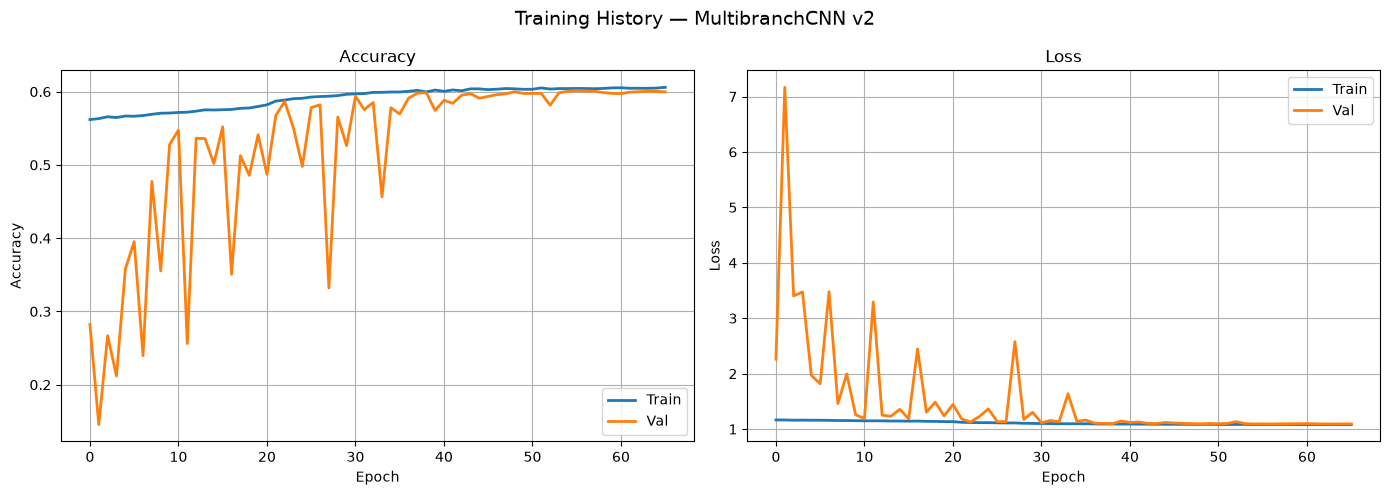

In [38]:
with open('history_v2_local.json', 'r') as f:
    h = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['accuracy'], label='Train', linewidth=2)
axes[0].plot(h['val_accuracy'], label='Val', linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(h['loss'], label='Train', linewidth=2)
axes[1].plot(h['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Training History — MultibranchCNN v2', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

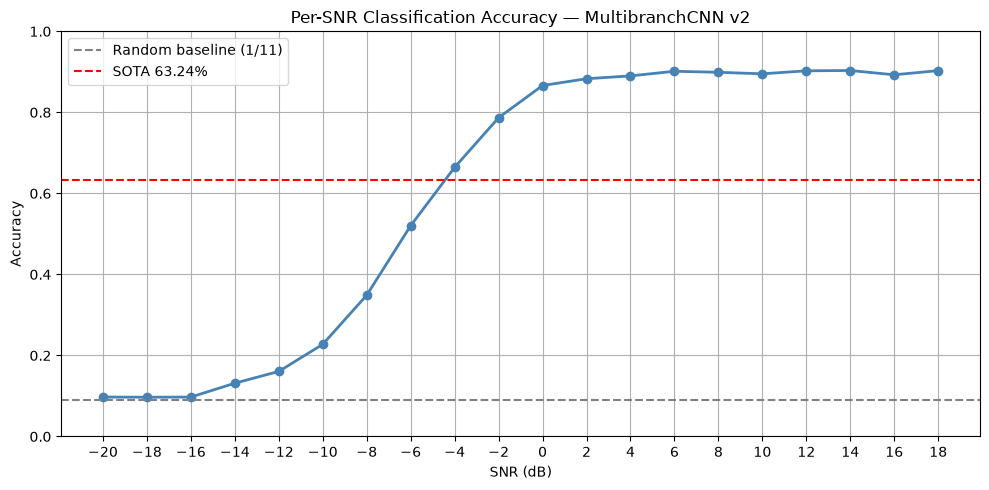

In [39]:
snr_vals = sorted(snr_acc.keys())
acc_vals = [snr_acc[s] for s in snr_vals]

plt.figure(figsize=(10, 5))
plt.plot(snr_vals, acc_vals, marker='o', linewidth=2, color='steelblue')
plt.axhline(1/11, color='gray', linestyle='--', label='Random baseline (1/11)')
plt.axhline(0.6324, color='red', linestyle='--', label='SOTA 63.24%')
plt.xlabel('SNR (dB)'); plt.ylabel('Accuracy')
plt.title('Per-SNR Classification Accuracy — MultibranchCNN v2')
plt.xticks(snr_vals); plt.ylim(0, 1)
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig('snr_accuracy.png', dpi=150)
plt.show()

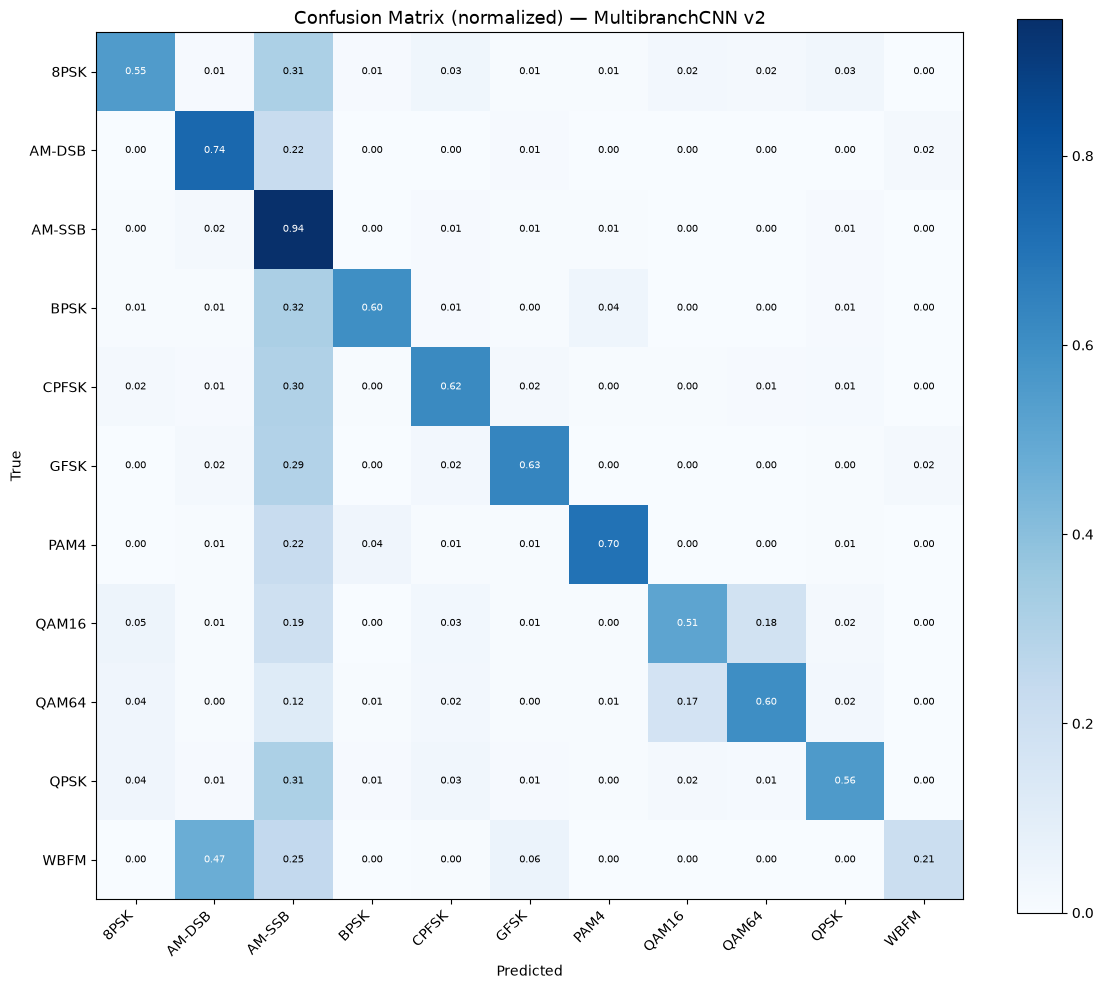

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.title('Confusion Matrix (normalized) — MultibranchCNN v2', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')

tick_marks = np.arange(len(mods))
plt.xticks(tick_marks, mods, rotation=45, ha='right')
plt.yticks(tick_marks, mods)

thresh = cm_norm.max() / 2.0
for i, j in itertools.product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    plt.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
              color='white' if cm_norm[i, j] > thresh else 'black', fontsize=7)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

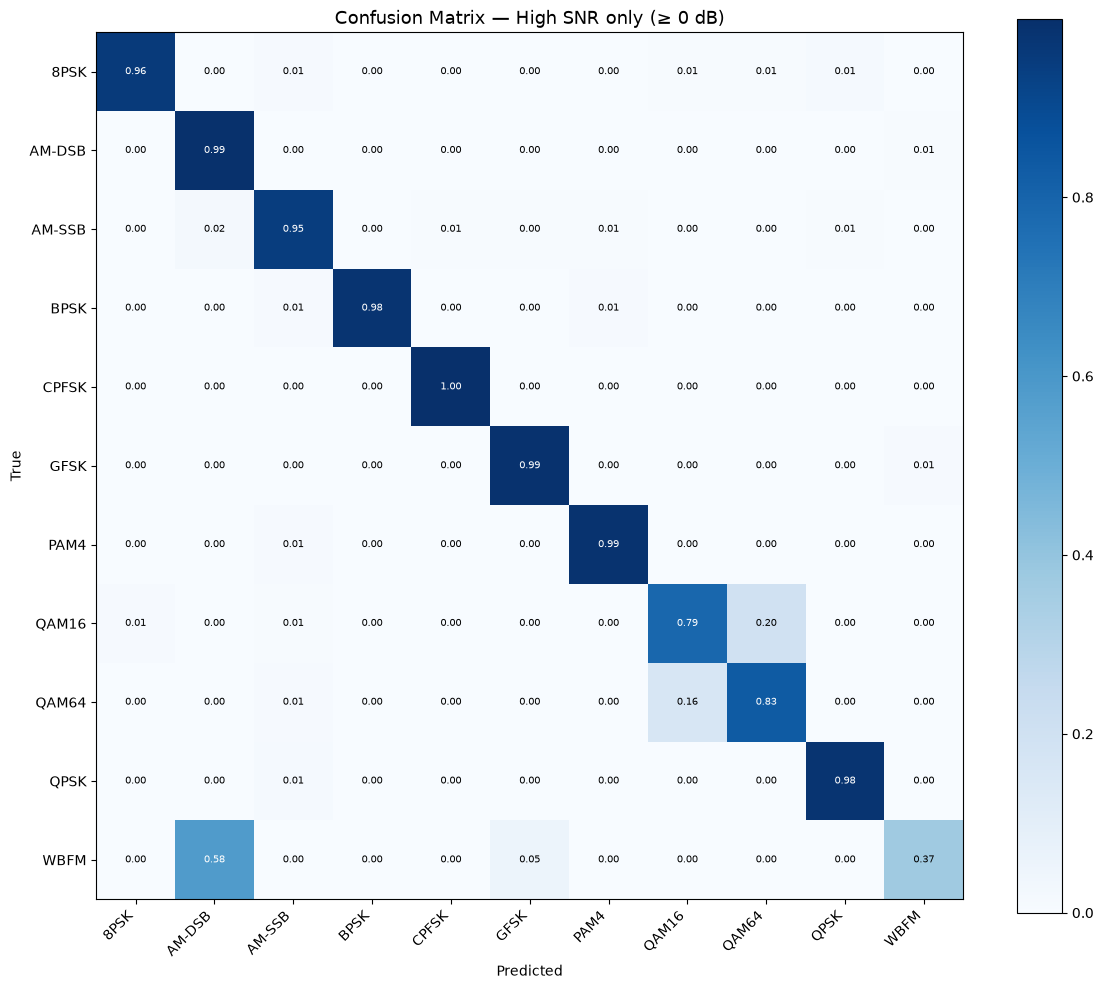

In [41]:
mask_high = snr_test >= 0
cm_high = confusion_matrix(y_true[mask_high], y_pred[mask_high])
cm_high_norm = cm_high.astype(float) / cm_high.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_high_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.title('Confusion Matrix — High SNR only (≥ 0 dB)', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(tick_marks, mods, rotation=45, ha='right')
plt.yticks(tick_marks, mods)

thresh = cm_high_norm.max() / 2.0
for i, j in itertools.product(range(cm_high_norm.shape[0]), range(cm_high_norm.shape[1])):
    plt.text(j, i, f'{cm_high_norm[i,j]:.2f}', ha='center', va='center',
              color='white' if cm_high_norm[i, j] > thresh else 'black', fontsize=7)

plt.tight_layout()
plt.savefig('confusion_matrix_high_snr.png', dpi=150)
plt.show()